<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/12_Cross_Validation_and_Model_Evaluation_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cross-Validation and Model Evaluation Techniques**

This notebook summarizes covers Cross-Validation and Model Evaluation Techniques:

1. Introduction to Cross-Validation (K-Fold and Stratified K-Fold)
2. Advanced Cross-Validation Methods (LOOCV and Nested CV)
3. Implementing Cross-Validation in scikit-learn
4. Model Selection Techniques (Grid Search and Randomized Search)
5. Evaluating Model Generalizability (Learning and Validation Curves)

# **1. Introduction to Cross-Validation**

A single train/test split is inherently noisy — the evaluation score depends heavily on which samples happened to land in the test set. **Cross-validation** addresses this by rotating multiple train/test splits across the data, averaging the results for a more stable, reliable estimate of generalization performance.

## **1.1 K-Fold Cross-Validation**

The dataset is divided into $k$ equal-sized **folds**. The model is trained $k$ times — each time using $k-1$ folds for training and the remaining fold for evaluation. The final score is the mean across all $k$ evaluations.

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score}(\hat{f}^{(-i)}, \mathcal{D}_i)$$

**Trade-off:** Larger $k$ = more stable estimate but higher computational cost. $k=5$ or $k=10$ are the most common choices.

## **1.2 Stratified K-Fold**

Standard K-Fold ignores class distribution — in imbalanced datasets, some folds may contain very few minority class samples. **Stratified K-Fold** preserves the original class proportions in each fold, yielding fairer and more reliable estimates for classification tasks.

| Method | Class Balance | Use Case |
|---|---|---|
| KFold | Not guaranteed | Regression, balanced classes |
| StratifiedKFold | Preserved per fold | Classification, especially imbalanced |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Synthetic classification dataset
X, y = make_classification(
    n_samples=500, n_features=10, n_informative=8,
    n_redundant=2, n_classes=2, random_state=2024
)

print(f"Dataset: {X.shape}, Class distribution: {np.bincount(y)}")

# Standard K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=2024)
kf_scores = []
for train_idx, test_idx in kf.split(X):
    model = LogisticRegression(max_iter=1000)
    model.fit(X[train_idx], y[train_idx])
    kf_scores.append(accuracy_score(y[test_idx], model.predict(X[test_idx])))

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
skf_scores = []
for train_idx, test_idx in skf.split(X, y):
    model = LogisticRegression(max_iter=1000)
    model.fit(X[train_idx], y[train_idx])
    skf_scores.append(accuracy_score(y[test_idx], model.predict(X[test_idx])))

print(f"\nKFold           — Mean: {np.mean(kf_scores):.4f}, Std: {np.std(kf_scores):.4f}")
print(f"StratifiedKFold — Mean: {np.mean(skf_scores):.4f}, Std: {np.std(skf_scores):.4f}")


Dataset: (500, 10), Class distribution: [250 250]

KFold           — Mean: 0.7560, Std: 0.0634
StratifiedKFold — Mean: 0.7660, Std: 0.0120


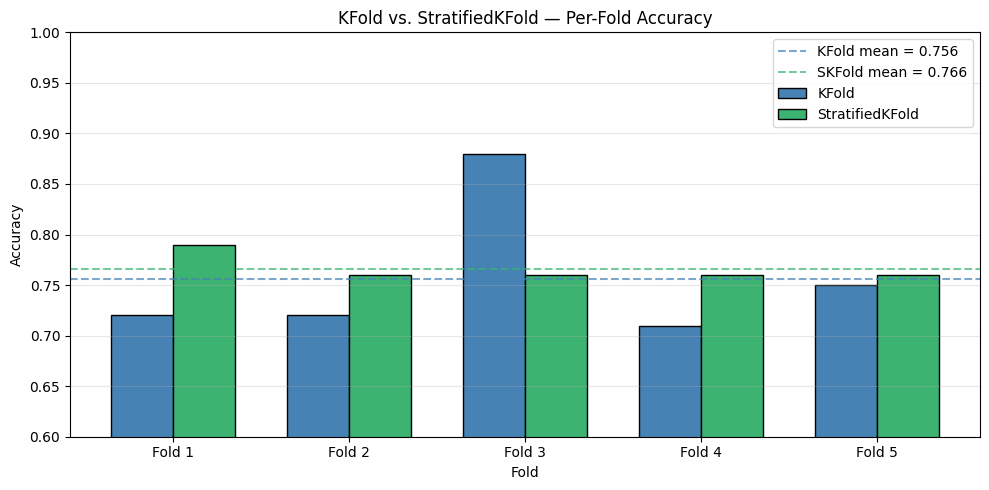

In [2]:
# Visualize per-fold accuracy comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, kf_scores,  width, label='KFold',           color='steelblue',     edgecolor='k')
bars2 = ax.bar(x + width/2, skf_scores, width, label='StratifiedKFold', color='mediumseagreen', edgecolor='k')

ax.axhline(np.mean(kf_scores),  color='steelblue',     linestyle='--', linewidth=1.5, alpha=0.7, label=f'KFold mean = {np.mean(kf_scores):.3f}')
ax.axhline(np.mean(skf_scores), color='mediumseagreen', linestyle='--', linewidth=1.5, alpha=0.7, label=f'SKFold mean = {np.mean(skf_scores):.3f}')

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('KFold vs. StratifiedKFold — Per-Fold Accuracy')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.6, 1.0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# **2. Advanced Cross-Validation Methods**

For small datasets or complex hyperparameter tuning, standard K-Fold may not be sufficient.

## **2.1 Leave-One-Out Cross-Validation (LOOCV)**

LOOCV is the extreme case of K-Fold where $k = n$ (one fold per sample):
- Each iteration trains on $n-1$ samples and tests on the single held-out sample
- Provides a nearly **unbiased estimate** of generalization error
- **Major limitation:** computationally expensive for large datasets

$$\text{LOOCV Error} = \frac{1}{n} \sum_{i=1}^{n} L(y_i, \hat{f}^{(-i)}(x_i))$$

## **2.2 Nested Cross-Validation**

When hyperparameter tuning and model evaluation happen on the same data, the evaluation is **optimistically biased** — the selected hyperparameters were tuned on the test fold. Nested CV prevents this:

- **Outer loop:** Evaluates the model's generalization performance
- **Inner loop:** Performs hyperparameter selection (e.g., GridSearchCV)


Outer fold 1 → [Inner GridSearchCV → best params] → evaluate on outer test fold
Outer fold 2 → [Inner GridSearchCV → best params] → evaluate on outer test fold
...
Final score = mean of outer fold scores (unbiased estimate)


This is the most rigorous approach to model selection when both tuning and evaluation are needed.

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge

# Load the diabetes regression dataset
data = load_diabetes()
X_d, y_d = data.data, data.target
print(f"Diabetes dataset: {X_d.shape}")

# LOOCV — unbiased but expensive
loo = LeaveOneOut()
loo_scores = cross_val_score(
    Ridge(alpha=1.0), X_d, y_d,
    cv=loo, scoring="neg_mean_squared_error"
)
print(f"\nLOOCV mean MSE : {-np.mean(loo_scores):,.2f}")

# Nested CV — prevents leakage between tuning and evaluation
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
inner_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
nested_scores = cross_val_score(inner_cv, X_d, y_d, cv=5)

print(f"Nested CV mean R²  : {np.mean(nested_scores):.4f}")
print(f"Nested CV score std: {np.std(nested_scores):.4f}")


Diabetes dataset: (442, 10)

LOOCV mean MSE : 3,327.66
Nested CV mean R²  : -3004.9478
Nested CV score std: 120.0485


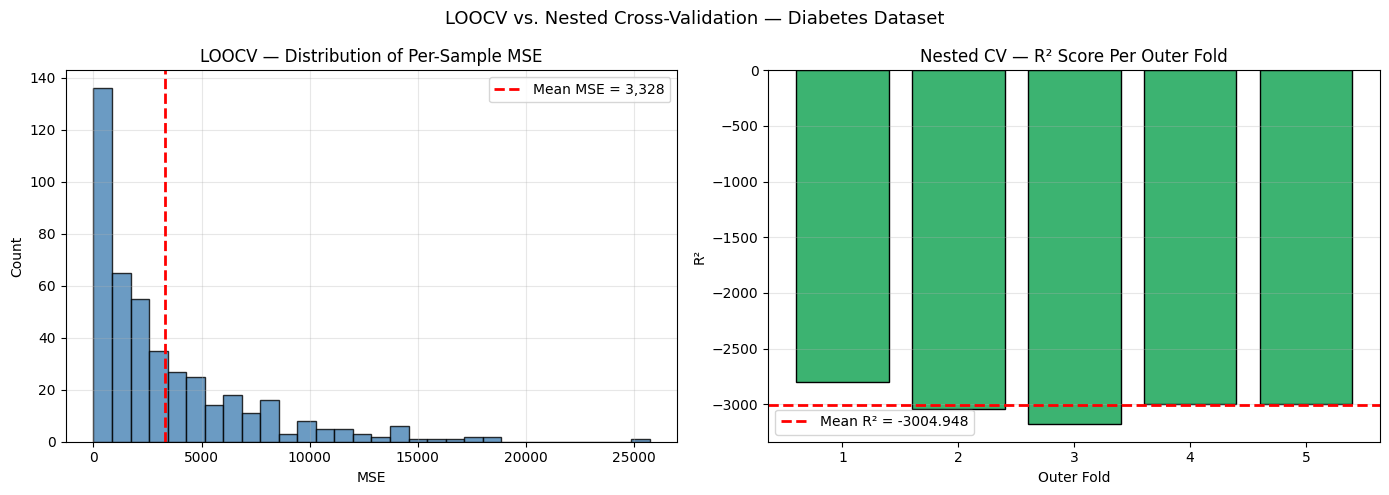

In [4]:
# Compare LOOCV vs Nested CV visually
methods  = ['LOOCV', 'Nested CV (R²)']
means    = [-np.mean(loo_scores)/10000, np.mean(nested_scores)]  # scale for visual
labels   = [f'MSE = {-np.mean(loo_scores):,.0f}', f'R² = {np.mean(nested_scores):.3f}']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOOCV distribution
axes[0].hist(-loo_scores, bins=30, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(-np.mean(loo_scores), color='red', linestyle='--', linewidth=2,
                label=f'Mean MSE = {-np.mean(loo_scores):,.0f}')
axes[0].set_title('LOOCV — Distribution of Per-Sample MSE')
axes[0].set_xlabel('MSE'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Nested CV fold scores
axes[1].bar(range(1, len(nested_scores)+1), nested_scores, color='mediumseagreen', edgecolor='k')
axes[1].axhline(np.mean(nested_scores), color='red', linestyle='--', linewidth=2,
                label=f'Mean R² = {np.mean(nested_scores):.3f}')
axes[1].set_title('Nested CV — R² Score Per Outer Fold')
axes[1].set_xlabel('Outer Fold'); axes[1].set_ylabel('R²')
axes[1].set_xticks(range(1, len(nested_scores)+1))
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('LOOCV vs. Nested Cross-Validation — Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()


# **3. Implementing Cross-Validation in scikit-learn**

scikit-learn provides three levels of API for implementing cross-validation, each with increasing capability:

## **3.1 cross_val_score() — Single Metric**

The simplest interface: pass a model, data, and scoring metric; receive an array of per-fold scores.

python
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')


## **3.2 cross_validate() — Multiple Metrics Simultaneously**

Returns a dictionary of arrays — one per metric — enabling richer model evaluation without re-running CV.

python
results = cross_validate(model, X, y, cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1'])


## **3.3 GridSearchCV() — Tuning Integrated with CV**

Combines hyperparameter search with cross-validation in a single estimator. Selects the best parameter combination based on the mean CV score across all folds.

## **3.4 Key scoring Strings**

| String | Metric |
|---|---|
| 'accuracy' | Classification accuracy |
| 'f1' | Binary F1-score |
| 'precision' | Binary precision |
| 'recall' | Binary recall |
| 'neg_mean_squared_error' | Negative MSE (regression) |
| 'r2' | R² coefficient (regression) |

In [5]:
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

# Imbalanced classification dataset (70/30 split)
X_cv, y_cv = make_classification(
    n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024
)

model_cv = LogisticRegression(max_iter=1000)

# 1. cross_val_score — single metric
cv_accuracy = cross_val_score(model_cv, X_cv, y_cv, cv=5, scoring='accuracy')
print(f"cross_val_score — Mean Accuracy: {np.mean(cv_accuracy):.4f} ± {np.std(cv_accuracy):.4f}")

# 2. cross_validate — multiple metrics
cv_results = cross_validate(
    model_cv, X_cv, y_cv, cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)
print(f"\ncross_validate results (mean across 5 folds):")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    vals = cv_results[f'test_{metric}']
    print(f"  {metric:<12}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# 3. GridSearchCV — hyperparameter tuning with CV
param_grid_cv = {"C": [0.01, 0.1, 1, 10]}
grid_cv = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_cv, cv=5, scoring='accuracy')
grid_cv.fit(X_cv, y_cv)
print(f"\nGridSearchCV — Best C: {grid_cv.best_params_['C']}, Best CV Accuracy: {grid_cv.best_score_:.4f}")


cross_val_score — Mean Accuracy: 0.9100 ± 0.0341

cross_validate results (mean across 5 folds):
  accuracy    : 0.9100 ± 0.0341
  precision   : 0.8750 ± 0.0655
  recall      : 0.8200 ± 0.0777
  f1          : 0.8446 ± 0.0601

GridSearchCV — Best C: 0.1, Best CV Accuracy: 0.9180


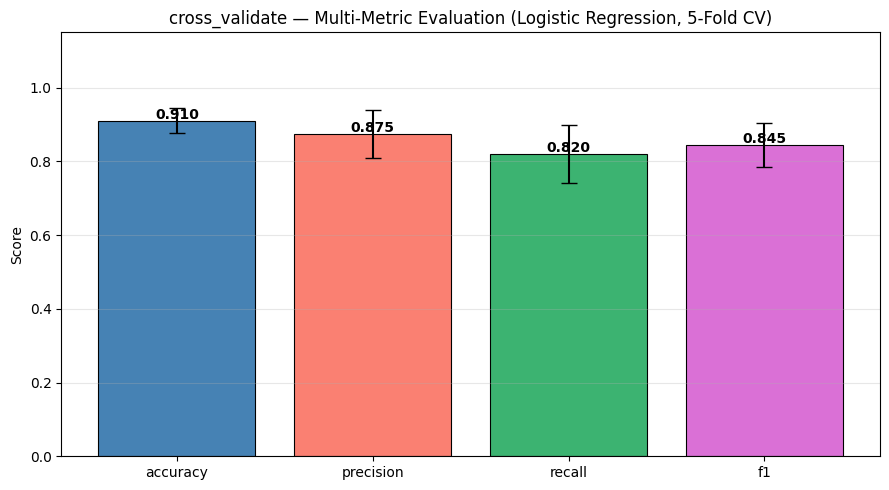

In [6]:
# Visualize cross_validate multi-metric results
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
means  = [np.mean(cv_results[f'test_{m}']) for m in metrics_names]
stds   = [np.std(cv_results[f'test_{m}'])  for m in metrics_names]
colors = ['steelblue', 'salmon', 'mediumseagreen', 'orchid']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics_names, means, yerr=stds, capsize=6,
              color=colors, edgecolor='k', linewidth=0.8)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('cross_validate — Multi-Metric Evaluation (Logistic Regression, 5-Fold CV)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# **4. Model Selection Techniques**

After establishing an evaluation framework via cross-validation, the next step is selecting the best model configuration. scikit-learn provides two complementary search strategies:

## **4.1 GridSearchCV — Exhaustive Search**

Tests every combination of specified hyperparameter values. Reliable but computationally expensive as the search space grows multiplicatively.

$$\text{Evaluations} = \prod_{i} |\text{grid}_i| \times k_{\text{cv}}$$

## **4.2 RandomizedSearchCV — Stochastic Search**

Samples a fixed number of combinations at random from continuous or discrete distributions. Often finds near-optimal results with far fewer evaluations than grid search.

python
from scipy.stats import loguniform
param_dist = {"C": loguniform(1e-3, 1e2)}
random_search = RandomizedSearchCV(..., n_iter=20, ...)


## **4.3 Trade-off Summary**

| Criterion | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Coverage | Exhaustive | Sampled |
| Speed | Slower | Faster |
| Large search space | Impractical | Well-suited |
| Reproducibility | Fully reproducible | Reproducible with random_state |

In [7]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import loguniform

X_sel, y_sel = make_classification(
    n_samples=500, n_features=10, weights=[0.7, 0.3], random_state=2024
)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_sel, y_sel, test_size=0.3, random_state=2024
)

# Grid Search
param_grid_sel = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_sel = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_sel, cv=5, scoring='accuracy')
grid_sel.fit(X_tr_s, y_tr_s)

# Randomized Search
param_dist_sel = {"C": loguniform(1e-3, 1e2)}
rand_sel = RandomizedSearchCV(
    LogisticRegression(max_iter=1000), param_dist_sel,
    n_iter=20, cv=5, scoring='accuracy', random_state=2024
)
rand_sel.fit(X_tr_s, y_tr_s)

print(f"GridSearchCV  — Best C: {grid_sel.best_params_['C']:.4f}, CV Score: {grid_sel.best_score_:.4f}")
print(f"RandomizedCV  — Best C: {rand_sel.best_params_['C']:.4f}, CV Score: {rand_sel.best_score_:.4f}")

# Final test evaluation
final_acc_grid = accuracy_score(y_te_s, grid_sel.best_estimator_.predict(X_te_s))
final_acc_rand = accuracy_score(y_te_s, rand_sel.best_estimator_.predict(X_te_s))
print(f"\nTest Accuracy  — GridSearch   : {final_acc_grid:.4f}")
print(f"Test Accuracy  — RandomSearch : {final_acc_rand:.4f}")


GridSearchCV  — Best C: 0.1000, CV Score: 0.8943
RandomizedCV  — Best C: 0.1744, CV Score: 0.8971

Test Accuracy  — GridSearch   : 0.9333
Test Accuracy  — RandomSearch : 0.9400


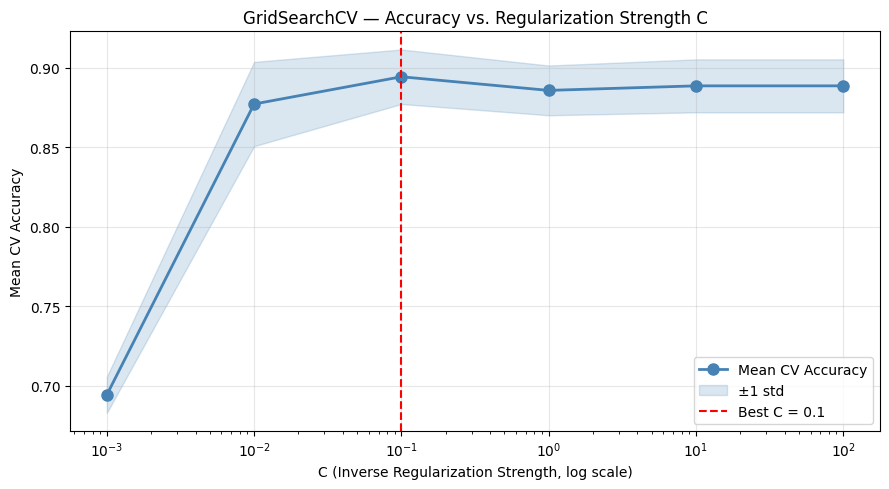

In [8]:
# Grid search CV results: mean score vs C
results_df = pd.DataFrame(grid_sel.cv_results_)
results_df['C'] = results_df['param_C'].astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(results_df['C'], results_df['mean_test_score'], 'o-',
            color='steelblue', linewidth=2, markersize=8, label='Mean CV Accuracy')
ax.fill_between(
    results_df['C'],
    results_df['mean_test_score'] - results_df['std_test_score'],
    results_df['mean_test_score'] + results_df['std_test_score'],
    alpha=0.2, color='steelblue', label='±1 std'
)
ax.axvline(grid_sel.best_params_['C'], color='red', linestyle='--',
           linewidth=1.5, label=f"Best C = {grid_sel.best_params_['C']}")
ax.set_xlabel('C (Inverse Regularization Strength, log scale)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('GridSearchCV — Accuracy vs. Regularization Strength C')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **5. Evaluating Model Generalizability**

Cross-validation scores tell us *what* a model achieves — learning and validation curves tell us *why* and help diagnose whether data collection or hyperparameter tuning is the right remedy.

## **5.1 Learning Curves**

A learning curve plots training and validation scores as a function of **training set size**. It reveals:

- **Underfitting (high bias):** Both training and validation scores are low, and close together. Adding more data won't help much — the model is too simple.
- **Overfitting (high variance):** Large gap between training (high) and validation (low) scores. Adding more data typically helps.
- **Well-generalized:** Both scores converge to a high value with increasing data.

## **5.2 Validation Curves**

A validation curve plots training and validation scores against a **hyperparameter value**. It reveals:

- **Too low C (strong regularization):** Both train and validation scores are low → underfitting
- **Too high C (weak regularization):** Train score high, validation score drops → overfitting
- **Optimal C:** Both scores are high and close together

## **5.3 The Law of Diminishing Returns**

Both curves typically plateau — adding more data or further tuning hyperparameters beyond a certain point yields negligible improvement. These curves help identify that optimal threshold.

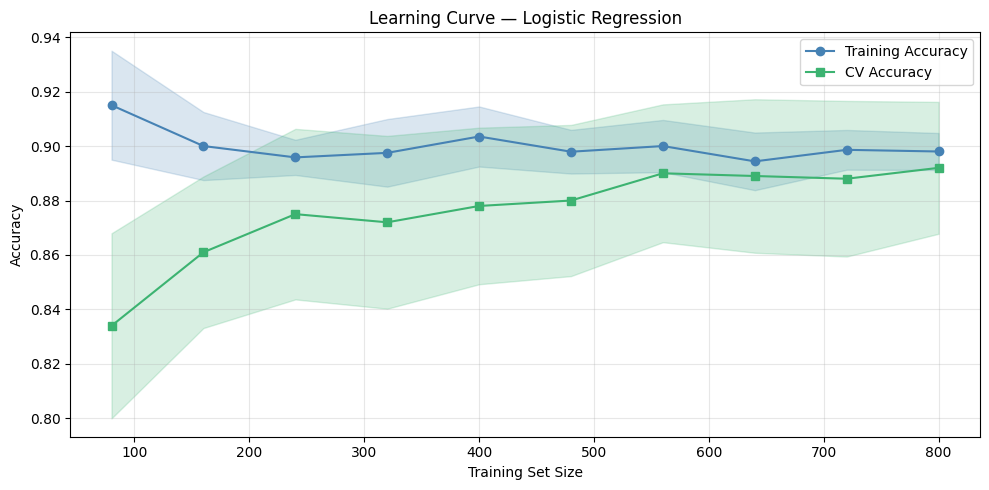

Gap (train - val) at 10% data: 0.0810
Gap (train - val) at 100% data: 0.0060
Interpretation: Gap narrowed significantly — good generalization


In [9]:
from sklearn.model_selection import learning_curve, validation_curve

X_gen, y_gen = make_classification(
    n_samples=1000, n_features=20, weights=[0.7, 0.3], random_state=2024
)

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), X_gen, y_gen,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=2024
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
val_mean   = np.mean(val_scores,   axis=1)
val_std    = np.std(val_scores,    axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',     label='Training Accuracy')
plt.plot(train_sizes, val_mean,   's-', color='mediumseagreen', label='CV Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.2, color='mediumseagreen')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key reading
gap_start = train_mean[0] - val_mean[0]
gap_end   = train_mean[-1] - val_mean[-1]
print(f"Gap (train - val) at 10% data: {gap_start:.4f}")
print(f"Gap (train - val) at 100% data: {gap_end:.4f}")
print(f"Interpretation: Gap {'narrowed significantly' if gap_end < gap_start/2 else 'persists'} — {'good generalization' if gap_end < 0.05 else 'consider more data or regularization'}")


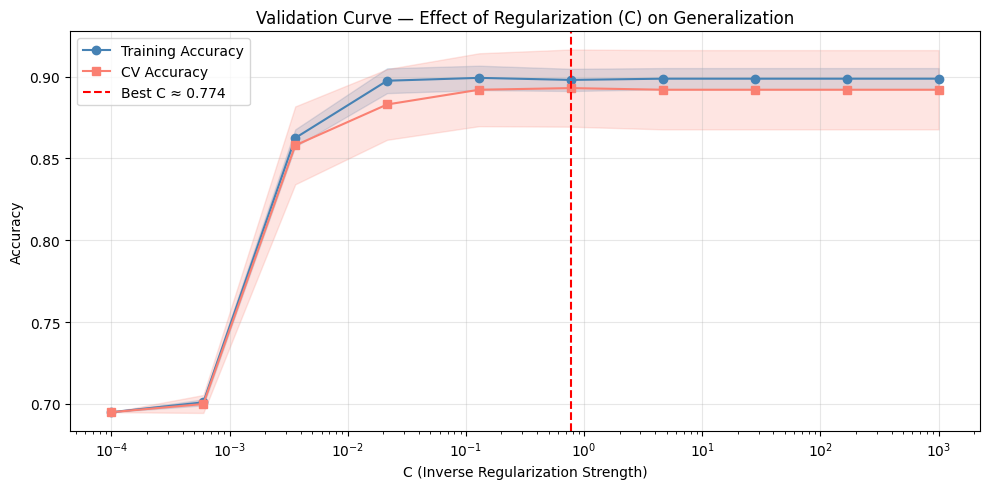

Best C from validation curve: 0.7743
Train accuracy at best C    : 0.8980
Val   accuracy at best C    : 0.8930


In [10]:
# Validation curve: accuracy vs C
param_range = np.logspace(-4, 3, 10)
tr_scores_vc, val_scores_vc = validation_curve(
    LogisticRegression(max_iter=1000), X_gen, y_gen,
    param_name="C", param_range=param_range,
    cv=5, scoring='accuracy'
)

tr_mean_vc  = np.mean(tr_scores_vc,  axis=1)
val_mean_vc = np.mean(val_scores_vc, axis=1)
tr_std_vc   = np.std(tr_scores_vc,   axis=1)
val_std_vc  = np.std(val_scores_vc,  axis=1)

plt.figure(figsize=(10, 5))
plt.semilogx(param_range, tr_mean_vc,  'o-', color='steelblue',     label='Training Accuracy')
plt.semilogx(param_range, val_mean_vc, 's-', color='salmon',         label='CV Accuracy')
plt.fill_between(param_range, tr_mean_vc  - tr_std_vc,  tr_mean_vc  + tr_std_vc,  alpha=0.2, color='steelblue')
plt.fill_between(param_range, val_mean_vc - val_std_vc, val_mean_vc + val_std_vc, alpha=0.2, color='salmon')

best_c_idx = np.argmax(val_mean_vc)
plt.axvline(param_range[best_c_idx], color='red', linestyle='--',
            label=f'Best C ≈ {param_range[best_c_idx]:.3f}')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Validation Curve — Effect of Regularization (C) on Generalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_c = param_range[best_c_idx]
print(f"Best C from validation curve: {best_c:.4f}")
print(f"Train accuracy at best C    : {tr_mean_vc[best_c_idx]:.4f}")
print(f"Val   accuracy at best C    : {val_mean_vc[best_c_idx]:.4f}")
